## Task 3 - Oasis Infobyte Internship

### Objective
Build a machine learning model to detect fraudulent credit card transactions from a highly imbalanced dataset.

### Dataset
Credit Card Fraud Detection Dataset from Kaggle.

### Technologies Used
Python, Pandas, NumPy, Scikit-learn, Imbalanced-learn, Matplotlib, Seaborn, and Jupyter Notebook.

### Steps
- Load and understand the dataset
- Analyze class imbalance
- Perform exploratory data analysis
- Analyze transaction amounts and time of day
- Apply SMOTE to handle class imbalance
- Train Logistic Regression and Random Forest models
- Evaluate models using Precision, Recall, F1-Score, and ROC-AUC
- Analyze feature importance
- Discuss model scalability

### Import Libraries & Load the Dataset

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Basic Inspection

In [3]:
df.shape

(284807, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Check Missing Values

In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


### Check Duplicate Transactions

In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1081


### Analyze Fraud vs Non-Fraud

In [9]:
class_counts = df["Class"].value_counts()

print(class_counts)

Class
0    284315
1       492
Name: count, dtype: int64


### Calculate Fraud Percentage

In [10]:
fraud_percentage = df["Class"].mean() * 100

print(f"Fraudulent transactions: {df['Class'].sum():,}")
print(f"Total transactions: {len(df):,}")
print(f"Fraud percentage: {fraud_percentage:.4f}%")

Fraudulent transactions: 492
Total transactions: 284,807
Fraud percentage: 0.1727%


### Class Imbalance Analysis

The dataset is extremely imbalanced. There are 284,315 legitimate transactions and only 492 fraudulent transactions. Fraudulent transactions represent approximately 0.17% of all transactions.

This severe imbalance creates a major challenge for machine learning because a model can achieve very high accuracy simply by predicting almost every transaction as legitimate.

For example, a model that predicts every transaction as non-fraud would achieve approximately 99.83% accuracy while completely failing to detect fraudulent transactions.

Therefore, accuracy alone is not an appropriate metric for this problem. Precision, Recall, F1-Score, and ROC-AUC should be considered when evaluating the fraud detection models.

### Visualize Class Imbalance

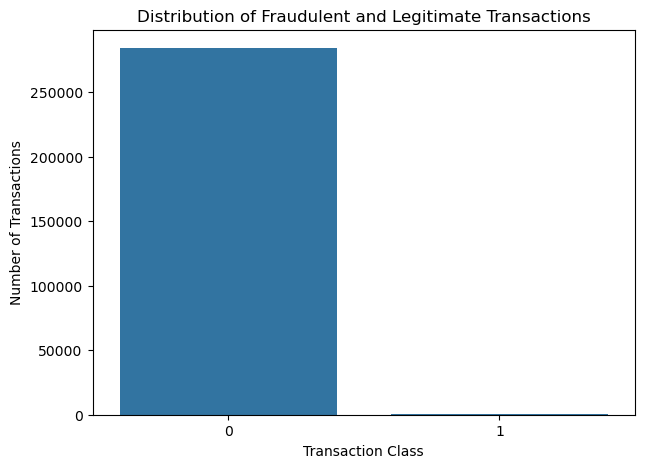

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Fraudulent and Legitimate Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

### Transaction Amount Analysis

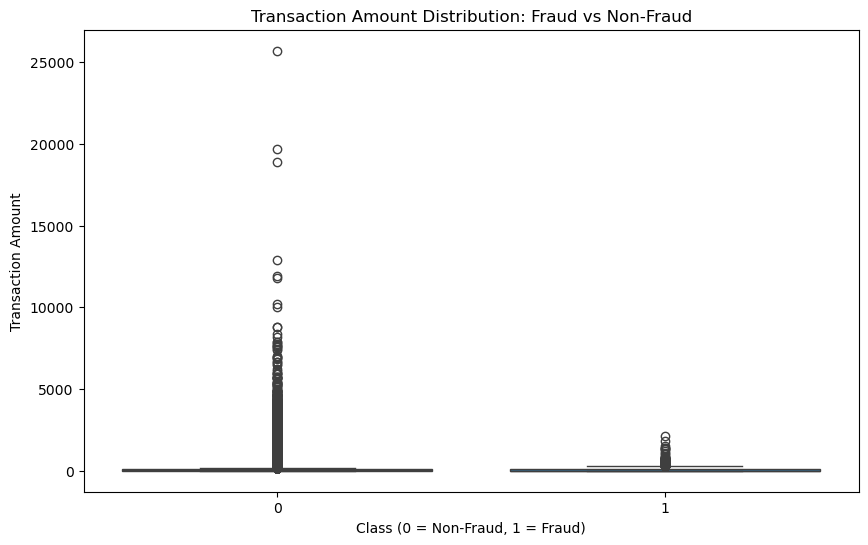

In [12]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount Distribution: Fraud vs Non-Fraud")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

### Compare Average Transaction Amount

In [13]:
df.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Class,,,,,
0,284315,88.291022,22.00,0.0,25691.16
1,492,122.211321,9.25,0.0,2125.87


### Better Amount Visualization

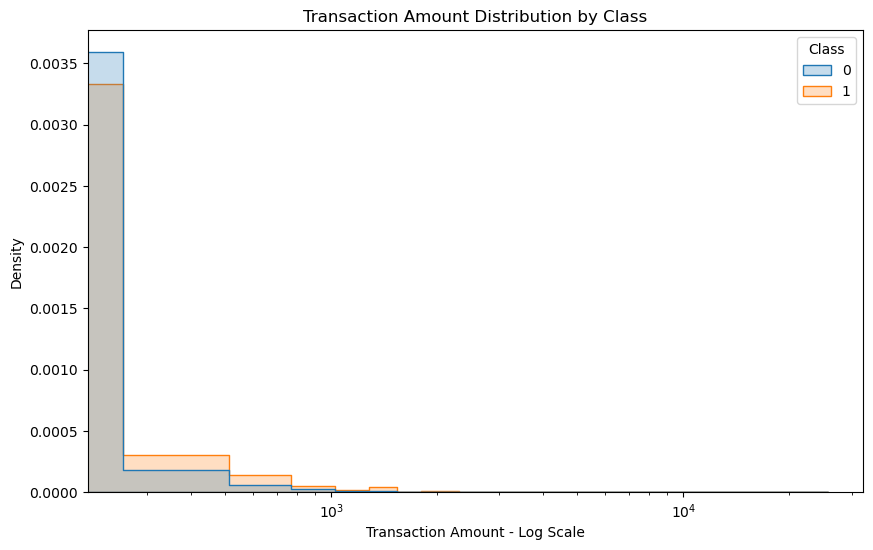

In [14]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)

plt.xscale("log")

plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Transaction Amount - Log Scale")
plt.ylabel("Density")

plt.show()

### Time-of-Day Analysis

In [15]:
df["Hour"] = ((df["Time"] // 3600) % 24).astype(int)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0


### Analyze Fraud by Hour

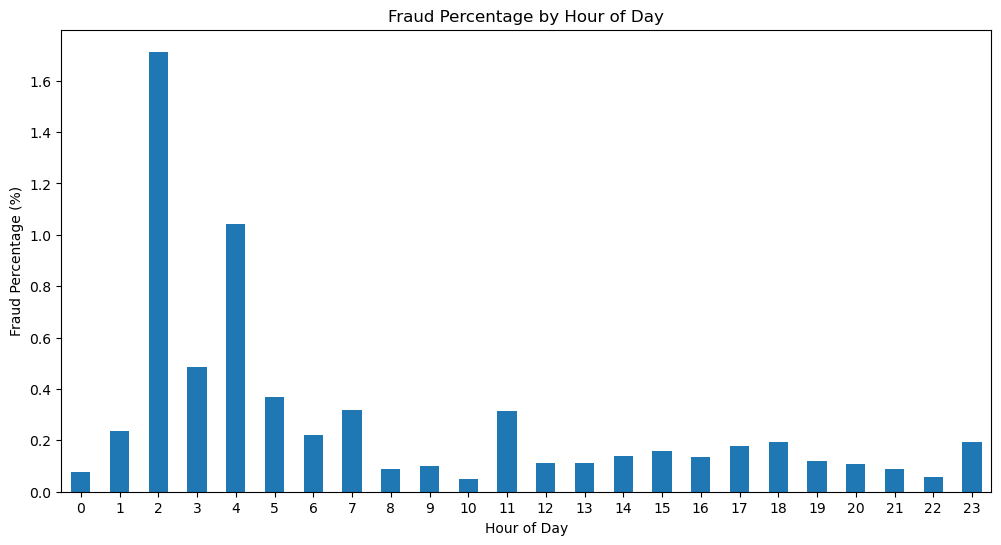

In [16]:
fraud_by_hour = df.groupby("Hour")["Class"].mean() * 100

plt.figure(figsize=(12, 6))

fraud_by_hour.plot(kind="bar")

plt.title("Fraud Percentage by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Percentage (%)")

plt.xticks(rotation=0)

plt.show()

### Number of Fraudulent Transactions by Hour

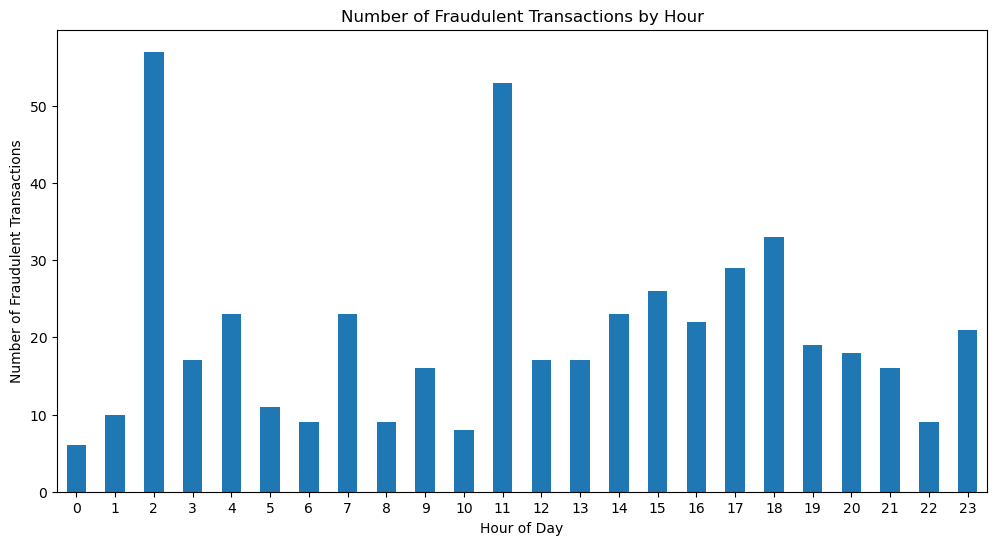

In [17]:
fraud_hour_count = (
    df[df["Class"] == 1]
    .groupby("Hour")
    .size()
)

plt.figure(figsize=(12, 6))

fraud_hour_count.plot(kind="bar")

plt.title("Number of Fraudulent Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Fraudulent Transactions")

plt.xticks(rotation=0)

plt.show()

## Time-of-Day Analysis

The transaction time was converted from seconds elapsed since the first transaction into an approximate hour-of-day feature.

Analyzing fraud activity by hour can reveal whether fraudulent transactions are concentrated during particular periods. However, because the dataset covers only approximately two days and the original timestamp is anonymized, the hour should be interpreted as a relative time-of-day indicator rather than a general real-world fraud pattern.

### Feature Engineering

In [18]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (284807, 31)
Target: (284807,)


### Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set: (227845, 31)
Testing set: (56962, 31)

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


### Scale the Features

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Feature scaling completed successfully!
Training data shape: (227845, 31)
Testing data shape: (56962, 31)


### Apply SMOTE

In [22]:
smote = SMOTE(
    sampling_strategy=0.1,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

  File "C:\Users\ASUS\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\ASUS\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ASUS\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ASUS\anaconda3\Lib\subprocess.py",

In [23]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1     22745
Name: count, dtype: int64


In [24]:
sampling_strategy=0.1

### Visualize Before vs After SMOTE

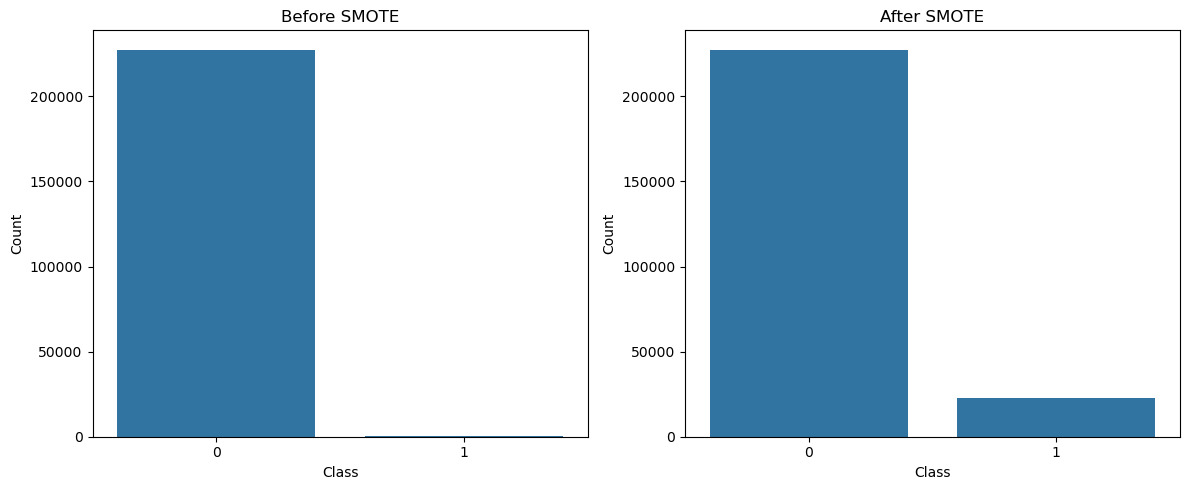

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

sns.countplot(x=y_train_smote, ax=axes[1])
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Model 1 — Logistic Regression

In [26]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_smote,
    y_train_smote
)

LogisticRegression(max_iter=1000, random_state=42)

### Make Predictions

In [27]:
y_pred_lr = logistic_model.predict(X_test_scaled)

y_prob_lr = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

### Evaluate Logistic Regression

In [28]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression")
print("----------------------------")
print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1-Score  : {lr_f1:.4f}")
print(f"ROC-AUC   : {lr_auc:.4f}")

Logistic Regression
----------------------------
Accuracy  : 0.9968
Precision : 0.3333
Recall    : 0.8878
F1-Score  : 0.4847
ROC-AUC   : 0.9687


### Logistic Regression Classification Report

In [29]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Non-Fraud", "Fraud"]
    )
)

              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56864
       Fraud       0.33      0.89      0.48        98

    accuracy                           1.00     56962
   macro avg       0.67      0.94      0.74     56962
weighted avg       1.00      1.00      1.00     56962



### Logistic Regression Confusion Matrix

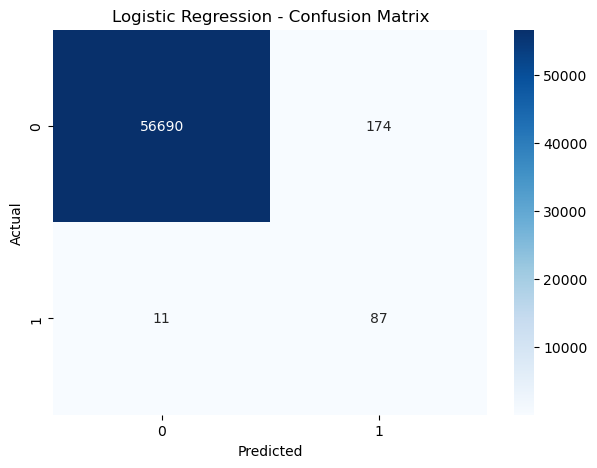

In [30]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Model 2 — Random Forest

In [31]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [32]:
class_weight="balanced"

### Random Forest Predictions

In [33]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(
    X_test
)[:, 1]

### Random Forest Evaluation

In [34]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest")
print("----------------------------")
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_auc:.4f}")

Random Forest
----------------------------
Accuracy  : 0.9995
Precision : 0.9610
Recall    : 0.7551
F1-Score  : 0.8457
ROC-AUC   : 0.9622


### Random Forest Classification Report

In [35]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Non-Fraud", "Fraud"]
    )
)

              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56864
       Fraud       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



### Random Forest Confusion Matrix

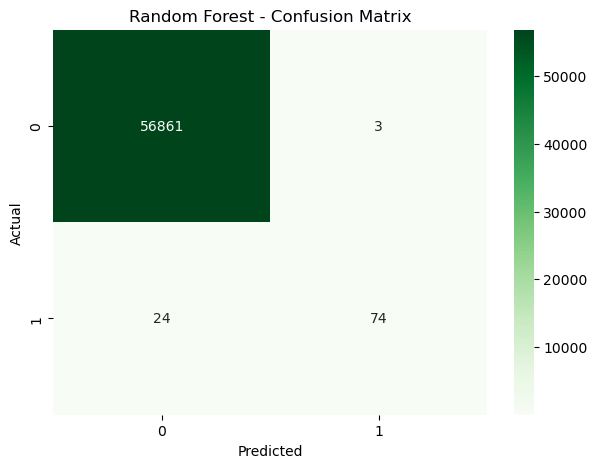

In [36]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Compare the Models

In [37]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "F1-Score": [
        lr_f1,
        rf_f1
    ],
    "ROC-AUC": [
        lr_auc,
        rf_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.996752,0.333333,0.887755,0.484680,0.968671
1,Random Forest,0.999526,0.961039,0.755102,0.845714,0.962229


### Plot Model Comparison

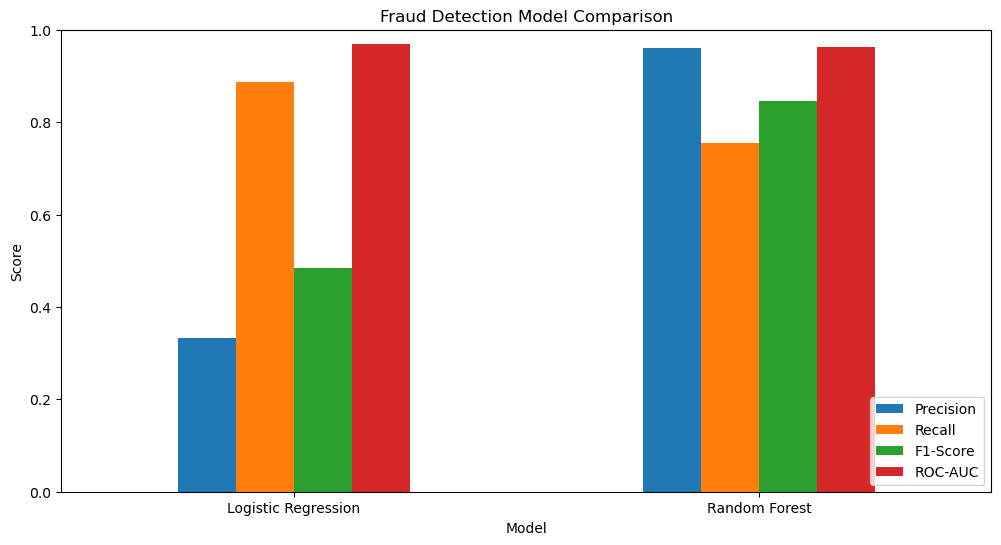

In [38]:
results.set_index("Model")[
    ["Precision", "Recall", "F1-Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Fraud Detection Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

### ROC-AUC Curve

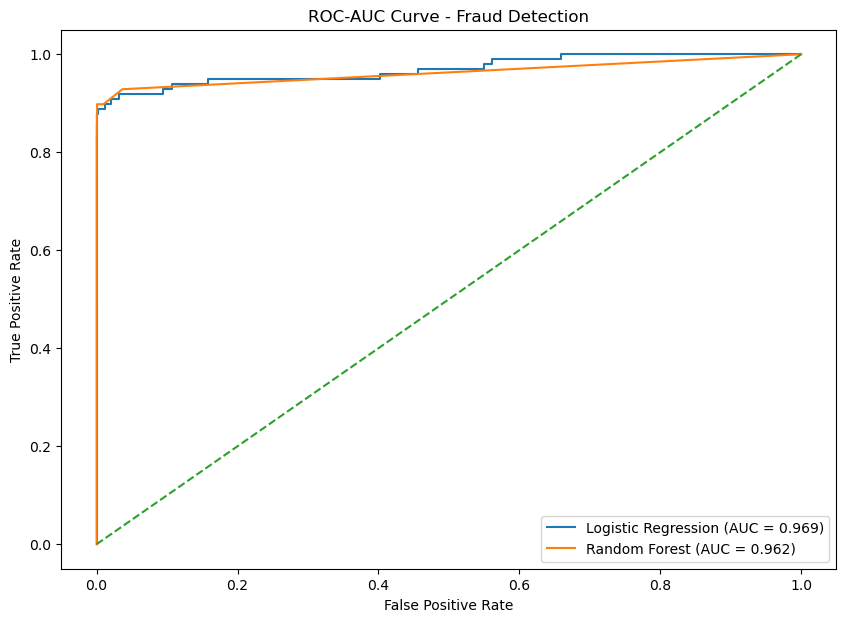

In [39]:
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(10, 7))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve - Fraud Detection")

plt.legend()

plt.show()

### Feature Importance

In [40]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
14,V14,0.188740
10,V10,0.136965
4,V4,0.091726
12,V12,0.091440
11,V11,0.075940
17,V17,0.075227
3,V3,0.055469
16,V16,0.034039
7,V7,0.033672
9,V9,0.021778


### Plot Feature Importance

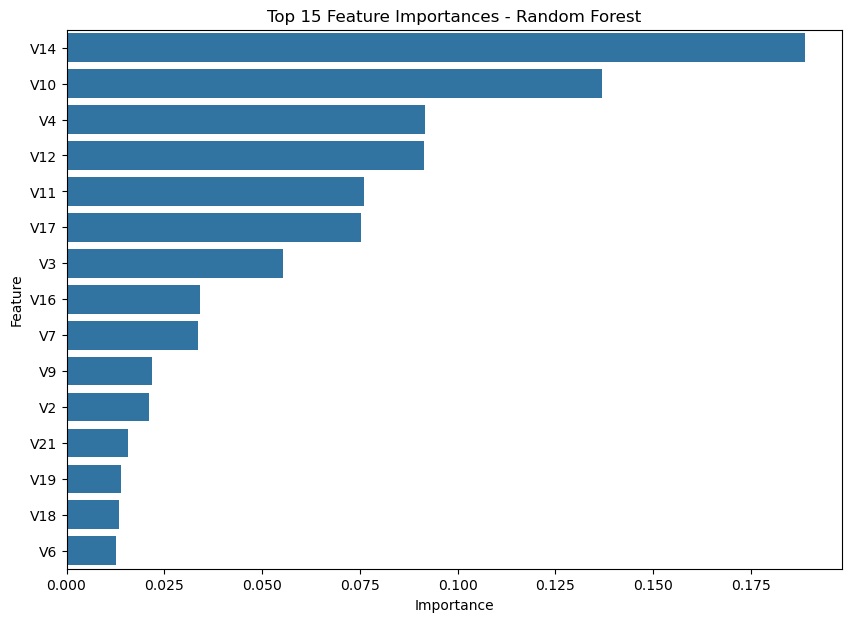

In [41]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Logistic Regression Coefficient Analysis

In [42]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

coefficients.head(15)

,Feature,Coefficient,Absolute_Coefficient
4,V4,1.424738,1.424738
10,V10,-0.867873,0.867873
0,Time,-0.818136,0.818136
14,V14,-0.606287,0.606287
30,Hour,0.480039,0.480039
5,V5,0.468283,0.468283
13,V13,-0.454096,0.454096
1,V1,0.430947,0.430947
12,V12,-0.427700,0.427700
16,V16,-0.427489,0.427489


## Which Metric Matters Most for Fraud Detection?

Accuracy is not the most important metric for this problem because the dataset is extremely imbalanced.

Recall is particularly important in fraud detection because it measures the percentage of actual fraudulent transactions that are successfully detected.

A low recall means that many fraudulent transactions are being classified as legitimate, which can result in financial losses.

However, maximizing recall alone is not sufficient. A model that flags almost every transaction as fraud may achieve very high recall but generate a large number of false alarms.

Precision therefore measures how many transactions predicted as fraudulent are actually fraudulent.

The practical objective is to find an appropriate balance between Recall and Precision. F1-Score provides a combined measure of Precision and Recall.

For this project, Recall is especially important when the cost of missing a fraudulent transaction is high, while Precision becomes increasingly important when false fraud alerts create significant operational costs.

### Accuracy vs Recall Example

In [43]:
dummy_accuracy = (y_test == 0).mean() * 100

print(
    f"If every transaction were predicted as non-fraud, "
    f"accuracy would be approximately {dummy_accuracy:.2f}%."
)

If every transaction were predicted as non-fraud, accuracy would be approximately 99.83%.


### Precision-Recall AUC

In [44]:
from sklearn.metrics import average_precision_score

pr_auc_lr = average_precision_score(
    y_test,
    y_prob_lr
)

pr_auc_rf = average_precision_score(
    y_test,
    y_prob_rf
)

print(f"Logistic Regression PR-AUC: {pr_auc_lr:.4f}")
print(f"Random Forest PR-AUC: {pr_auc_rf:.4f}")

Logistic Regression PR-AUC: 0.7522
Random Forest PR-AUC: 0.8669


## Scalability: Handling 1 Million Transactions per Hour

A production fraud detection system processing 1 million transactions per hour would need to process approximately 278 transactions per second.

The trained model itself can be used for fast inference because prediction is significantly cheaper than model training. However, a production system would require an efficient real-time architecture.

A scalable implementation could include:

1. A streaming platform such as Apache Kafka for receiving transactions.
2. A preprocessing service for validating and transforming transaction data.
3. A trained machine learning model served through an API using FastAPI or a similar framework.
4. Multiple model-serving instances behind a load balancer.
5. A low-latency database or feature store for retrieving historical transaction features.
6. Monitoring for model drift, changes in fraud patterns, latency, and prediction quality.
7. Periodic retraining using newly labeled transactions.

The model could therefore be deployed as a real-time scoring service. Horizontal scaling would allow multiple inference instances to process transactions concurrently.

For 1 million transactions per hour, approximately 278 transactions per second would need to be processed on average. The exact infrastructure requirements would depend on feature-generation complexity, model size, latency requirements, and peak traffic rather than the average transaction rate alone.

# Conclusion

This project developed a machine learning pipeline for detecting fraudulent credit card transactions using a highly imbalanced dataset.

The dataset contained 284,807 transactions, with only 492 fraudulent transactions, making class imbalance the primary challenge.

Exploratory Data Analysis was performed to understand the class distribution, transaction amounts, and time-of-day patterns. The analysis demonstrated that standard accuracy is not sufficient for evaluating a fraud detection model because a model can achieve high accuracy while failing to identify fraudulent transactions.

A stratified train-test split was used to ensure that fraudulent transactions were represented in both datasets. SMOTE was then applied only to the training data to address class imbalance without causing data leakage.

Two machine learning models were trained and evaluated:

- Logistic Regression
- Random Forest

The models were evaluated using Precision, Recall, F1-Score, ROC-AUC, and confusion matrices rather than relying solely on accuracy.

Recall is particularly important for fraud detection because failing to identify a fraudulent transaction can result in financial losses. However, precision must also be considered because excessive false positives can result in unnecessary transaction reviews and customer inconvenience.

Feature importance analysis using Random Forest provided insight into the features that contributed most strongly to fraud predictions. Since V1–V28 are anonymized PCA-transformed features, their individual business meaning cannot be directly interpreted.

Finally, the project considered production scalability. A system processing 1 million transactions per hour would require approximately 278 transactions per second on average. A real-time architecture using streaming, scalable model-serving infrastructure, monitoring, and periodic retraining could be used to support such workloads.

Overall, this project demonstrates how machine learning, class-imbalance handling, appropriate evaluation metrics, and scalable architecture can be combined to build a practical fraud detection system.